In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:

SYNTHETIC_DATA_PATH = Path("tabddpm/synthetic_data.csv")
CONNECTION_DURATION_COL = "Target"  # TabDDPM uses 'Target' for connection_duration

# SYNTHETIC_DATA_PATH = Path("CTGAN/synthetic_data.csv")
# CONNECTION_DURATION_COL = "connection_duration"

OUTPUT_PATH = SYNTHETIC_DATA_PATH.parent / f"{SYNTHETIC_DATA_PATH.stem}_postprocessed.csv"

In [3]:
# Load synthetic data
df = pd.read_csv(SYNTHETIC_DATA_PATH)
print(f"Loaded {len(df)} rows from {SYNTHETIC_DATA_PATH}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Loaded 18315 rows from tabddpm\synthetic_data.csv

Columns: ['handshake_duration', 'time_to_migration', 'migration_duration', 'packets_before_migration', 'total_bidi_streams_client_init', 'total_udi_streams_client_init', 'bytes_sent_client', 'bytes_sent_server', 'implementation', 'version_negotiation_occurred', 'retry_occurred', 'migration_type', 'path_validation_initiated', 'connection_close_type', 'Target']


,handshake_duration,time_to_migration,migration_duration,packets_before_migration,total_bidi_streams_client_init,total_udi_streams_client_init,bytes_sent_client,bytes_sent_server,implementation,version_negotiation_occurred,retry_occurred,migration_type,path_validation_initiated,connection_close_type,Target
0,11.316725,76.932842,1.438115,11.0,1.0,4.0,3306.049795,3320.670906,aioquic,No,No,DURING_DOWNLOAD,Yes,CLIENT_CLOSE,199.653611
1,11.077198,13.246599,1.197275,13.0,1.0,4.0,7269.000000,4568.000000,quiche,Yes,Yes,BEFORE_DOWNLOAD,Yes,CLIENT_CLOSE,22.184177
2,9.372889,10.523408,0.876488,13.0,1.0,4.0,7194.000000,4568.000000,quiche,Yes,Yes,BEFORE_DOWNLOAD,Yes,CLIENT_CLOSE,15.529131
3,9.788690,75.498776,1.243164,12.0,1.0,4.0,3299.462930,3244.042239,aioquic,No,No,AFTER_DOWNLOAD,Yes,CLIENT_CLOSE,1081.995713
4,2.381119,2.384599,0.133592,11.0,1.0,1.0,5677.000000,4675.000000,quicgo,No,No,BEFORE_DOWNLOAD,Yes,CLIENT_CLOSE,2.840554


In [4]:
# Rename Target to connection_duration for consistent processing
if CONNECTION_DURATION_COL != "connection_duration":
    df = df.rename(columns={CONNECTION_DURATION_COL: "connection_duration"})
    print(f"Renamed '{CONNECTION_DURATION_COL}' to 'connection_duration'")

Renamed 'Target' to 'connection_duration'


## Analyze Violations Before Post-Processing

In [5]:
def analyze_violations(df):
    """Analyze and report constraint violations in the dataset."""
    violations = {}
    
    # Duration columns that should be <= connection_duration
    duration_cols = ['handshake_duration', 'time_to_migration', 'migration_duration']
    
    print("=" * 60)
    print("CONSTRAINT VIOLATION ANALYSIS")
    print("=" * 60)
    
    # Check non-negativity
    print("\n1. NON-NEGATIVITY VIOLATIONS:")
    print("-" * 40)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        neg_count = (df[col] < 0).sum()
        if neg_count > 0:
            violations[f"{col}_negative"] = neg_count
            print(f"  {col}: {neg_count} negative values ({neg_count/len(df)*100:.2f}%)")
    if not any(k.endswith('_negative') for k in violations):
        print("  No negative values found.")
    
    # Check duration constraints
    print("\n2. DURATION CONSTRAINT VIOLATIONS (should be <= connection_duration):")
    print("-" * 40)
    for col in duration_cols:
        if col in df.columns:
            violation_count = (df[col] > df['connection_duration']).sum()
            if violation_count > 0:
                violations[f"{col}_exceeds_connection"] = violation_count
                max_excess = (df[col] - df['connection_duration']).max()
                print(f"  {col} > connection_duration: {violation_count} rows ({violation_count/len(df)*100:.2f}%)")
                print(f"    Max excess: {max_excess:.4f}")
            else:
                print(f"  {col}: OK")
    
    # Check combined duration constraint (handshake + migration <= connection)
    print("\n3. COMBINED DURATION VIOLATIONS:")
    print("-" * 40)
    if 'handshake_duration' in df.columns and 'migration_duration' in df.columns:
        combined = df['handshake_duration'] + df['migration_duration']
        violation_count = (combined > df['connection_duration']).sum()
        if violation_count > 0:
            violations['combined_duration_exceeds'] = violation_count
            print(f"  handshake + migration > connection: {violation_count} rows ({violation_count/len(df)*100:.2f}%)")
        else:
            print(f"  handshake + migration <= connection: OK")
    
    # Check time_to_migration should be >= handshake_duration (logically, migration happens after handshake)
    if 'time_to_migration' in df.columns and 'handshake_duration' in df.columns:
        # Note: This might not always be a violation depending on when migration is measured
        violation_count = (df['time_to_migration'] < df['handshake_duration']).sum()
        if violation_count > 0:
            print(f"  time_to_migration < handshake_duration: {violation_count} rows (may need review)")
    
    print("\n" + "=" * 60)
    print(f"TOTAL TYPES OF VIOLATIONS: {len(violations)}")
    print("=" * 60)
    
    return violations

violations_before = analyze_violations(df)

CONSTRAINT VIOLATION ANALYSIS

1. NON-NEGATIVITY VIOLATIONS:
----------------------------------------
  No negative values found.

2. DURATION CONSTRAINT VIOLATIONS (should be <= connection_duration):
----------------------------------------
  handshake_duration > connection_duration: 214 rows (1.17%)
    Max excess: 263.1438
  time_to_migration > connection_duration: 420 rows (2.29%)
    Max excess: 298.9805
  migration_duration > connection_duration: 47 rows (0.26%)
    Max excess: 70.0909

3. COMBINED DURATION VIOLATIONS:
----------------------------------------
  handshake + migration > connection: 504 rows (2.75%)
  time_to_migration < handshake_duration: 1092 rows (may need review)

TOTAL TYPES OF VIOLATIONS: 4


## Post-Processing Functions

In [6]:
def clip_to_non_negative(df, columns=None):
    """
    Clip all numeric columns (or specified columns) to be >= 0.
    """
    df = df.copy()
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns
    
    for col in columns:
        if col in df.columns:
            before = (df[col] < 0).sum()
            df[col] = df[col].clip(lower=0)
            if before > 0:
                print(f"  Clipped {before} negative values in '{col}'")
    
    return df

In [7]:
def fix_duration_constraints(df, method='clip'):
    """
    Fix duration constraints so sub-durations don't exceed connection_duration.
    
    Methods:
    - 'clip': Clip values to connection_duration
    - 'scale': Scale proportionally to fit within connection_duration
    - 'drop': Drop rows with violations
    """
    df = df.copy()
    duration_cols = ['handshake_duration', 'time_to_migration', 'migration_duration', 
                     'first_path_validation_response_latency']
    
    print(f"\nApplying duration constraint fix (method: {method})")
    
    if method == 'clip':
        for col in duration_cols:
            if col in df.columns:
                before = (df[col] > df['connection_duration']).sum()
                df[col] = df[[col, 'connection_duration']].min(axis=1)
                if before > 0:
                    print(f"  Clipped {before} values in '{col}' to connection_duration")
    
    elif method == 'scale':
        # Find rows where sum of durations exceeds connection_duration
        existing_cols = [c for c in duration_cols if c in df.columns]
        if existing_cols:
            for idx in df.index:
                conn_dur = df.loc[idx, 'connection_duration']
                for col in existing_cols:
                    if df.loc[idx, col] > conn_dur:
                        # Scale down proportionally
                        df.loc[idx, col] = conn_dur * 0.9  # Leave 10% margin
    
    elif method == 'drop':
        initial_len = len(df)
        for col in duration_cols:
            if col in df.columns:
                df = df[df[col] <= df['connection_duration']]
        dropped = initial_len - len(df)
        if dropped > 0:
            print(f"  Dropped {dropped} rows with duration violations")
    
    return df

In [8]:
def fix_combined_duration_constraint(df, method='scale'):
    """
    Ensure handshake_duration + migration_duration <= connection_duration.
    
    Methods:
    - 'scale': Scale both proportionally
    - 'prioritize_handshake': Keep handshake, reduce migration
    - 'drop': Drop violating rows
    """
    df = df.copy()
    
    if 'handshake_duration' not in df.columns or 'migration_duration' not in df.columns:
        return df
    
    print(f"\nApplying combined duration constraint fix (method: {method})")
    
    combined = df['handshake_duration'] + df['migration_duration']
    violations = combined > df['connection_duration']
    violation_count = violations.sum()
    
    if violation_count == 0:
        print("  No combined duration violations to fix.")
        return df
    
    if method == 'scale':
        # Scale both proportionally where there are violations
        for idx in df[violations].index:
            conn_dur = df.loc[idx, 'connection_duration']
            hs_dur = df.loc[idx, 'handshake_duration']
            mig_dur = df.loc[idx, 'migration_duration']
            total = hs_dur + mig_dur
            
            if total > 0:
                scale_factor = conn_dur * 0.95 / total  # Leave 5% margin
                df.loc[idx, 'handshake_duration'] = hs_dur * scale_factor
                df.loc[idx, 'migration_duration'] = mig_dur * scale_factor
        print(f"  Scaled {violation_count} rows with combined duration violations")
    
    elif method == 'prioritize_handshake':
        # Keep handshake as is, reduce migration to fit
        for idx in df[violations].index:
            remaining = df.loc[idx, 'connection_duration'] - df.loc[idx, 'handshake_duration']
            df.loc[idx, 'migration_duration'] = max(0, remaining * 0.9)
        print(f"  Adjusted migration_duration in {violation_count} rows")
    
    elif method == 'drop':
        df = df[~violations]
        print(f"  Dropped {violation_count} rows with combined duration violations")
    
    return df

In [9]:
def fix_integer_columns(df):
    """
    Round columns that should be integers to nearest integer.
    """
    df = df.copy()
    
    # Columns that should be integers
    int_cols = [
        'packets_before_migration', 'total_bidi_streams_client_init', 
        'total_bidi_streams_server_init', 'total_udi_streams_client_init',
        'total_udi_streams_server_init', 'bytes_sent_client', 'bytes_sent_server',
        'packets_sent_client', 'packets_sent_server', 'quic_packets_sent_client',
        'quic_packets_sent_server', 'new_connection_ids_issued_server',
        'new_connection_ids_issued_client', 'retired_cid_count_client',
        'retired_cid_count_server', 'ack_sent_client', 'ack_sent_server',
        'crypto_sent_client', 'crypto_sent_server', 'handshake_done_client',
        'handshake_done_server', 'path_challenge_sent_client', 
        'path_challenge_sent_server', 'path_response_sent_client',
        'path_response_sent_server', 'mtu', 'app_data_bytes_before_migration',
        'padding_bytes_in_validation_pc', 'padding_bytes_in_validation_pr',
        'bytes_bidi_streams_client_init_client_sent',
        'bytes_bidi_streams_client_init_server_sent',
        'bytes_bidi_streams_server_init_client_sent',
        'bytes_bidi_streams_server_init_server_sent',
        'bytes_udi_streams_client_init', 'bytes_udi_streams_server_init',
        'total_client_app_bytes', 'total_server_app_bytes'
    ]
    
    print("\nRounding integer columns...")
    for col in int_cols:
        if col in df.columns:
            df[col] = df[col].round().astype(int)
    
    return df

In [10]:
def fix_logical_constraints(df):
    """
    Apply additional logical constraints.
    """
    df = df.copy()
    
    print("\nApplying additional logical constraints...")
    
    # time_to_migration should be >= handshake_duration (migration starts after handshake)
    if 'time_to_migration' in df.columns and 'handshake_duration' in df.columns:
        violations = df['time_to_migration'] < df['handshake_duration']
        if violations.sum() > 0:
            # Set time_to_migration to be at least handshake_duration
            df.loc[violations, 'time_to_migration'] = df.loc[violations, 'handshake_duration']
            print(f"  Adjusted {violations.sum()} rows where time_to_migration < handshake_duration")
    
    # Ensure time_to_migration + migration_duration <= connection_duration
    if all(c in df.columns for c in ['time_to_migration', 'migration_duration', 'connection_duration']):
        combined = df['time_to_migration'] + df['migration_duration']
        violations = combined > df['connection_duration']
        if violations.sum() > 0:
            # Reduce migration_duration to fit
            for idx in df[violations].index:
                max_mig = df.loc[idx, 'connection_duration'] - df.loc[idx, 'time_to_migration']
                df.loc[idx, 'migration_duration'] = max(0, max_mig * 0.95)
            print(f"  Adjusted {violations.sum()} rows where time_to_migration + migration_duration > connection_duration")
    
    return df

## Apply Post-Processing

In [11]:
def apply_post_processing(df, 
                          duration_method='clip',
                          combined_duration_method='scale',
                          fix_integers=True,
                          fix_logical=True):
    """
    Apply all post-processing rules to the synthetic data.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Synthetic data to post-process
    duration_method : str
        Method for fixing individual duration constraints ('clip', 'scale', 'drop')
    combined_duration_method : str
        Method for fixing combined duration constraint ('scale', 'prioritize_handshake', 'drop')
    fix_integers : bool
        Whether to round integer columns
    fix_logical : bool
        Whether to apply additional logical constraints
    
    Returns:
    --------
    pd.DataFrame
        Post-processed data
    """
    print("\n" + "="*60)
    print("APPLYING POST-PROCESSING RULES")
    print("="*60)
    
    # Step 1: Fix non-negative constraints
    print("\n1. Fixing non-negative constraints...")
    df = clip_to_non_negative(df)
    
    # Step 2: Fix individual duration constraints
    print("\n2. Fixing individual duration constraints...")
    df = fix_duration_constraints(df, method=duration_method)
    
    # Step 3: Fix combined duration constraints
    print("\n3. Fixing combined duration constraints...")
    df = fix_combined_duration_constraint(df, method=combined_duration_method)
    
    # Step 4: Apply additional logical constraints
    if fix_logical:
        print("\n4. Fixing additional logical constraints...")
        df = fix_logical_constraints(df)
    
    # Step 5: Fix integer columns
    if fix_integers:
        print("\n5. Fixing integer columns...")
        df = fix_integer_columns(df)
    
    print("\n" + "="*60)
    print("POST-PROCESSING COMPLETE")
    print("="*60)
    
    return df

In [12]:
# Apply post-processing with your preferred methods
df_processed = apply_post_processing(
    df,
    duration_method='scale',          # 'clip', 'scale', or 'drop'
    combined_duration_method='scale', # 'scale', 'prioritize_handshake', or 'drop'
    fix_integers=True,
    fix_logical=True
)


APPLYING POST-PROCESSING RULES

1. Fixing non-negative constraints...

2. Fixing individual duration constraints...

Applying duration constraint fix (method: clip)
  Clipped 214 values in 'handshake_duration' to connection_duration
  Clipped 420 values in 'time_to_migration' to connection_duration
  Clipped 47 values in 'migration_duration' to connection_duration

3. Fixing combined duration constraints...

Applying combined duration constraint fix (method: scale)
  Scaled 503 rows with combined duration violations

4. Fixing additional logical constraints...

Applying additional logical constraints...
  Adjusted 964 rows where time_to_migration < handshake_duration
  Adjusted 815 rows where time_to_migration + migration_duration > connection_duration

5. Fixing integer columns...

Rounding integer columns...

POST-PROCESSING COMPLETE


## Verify Results

In [13]:
print("\nVIOLATIONS AFTER POST-PROCESSING:")
violations_after = analyze_violations(df_processed)


VIOLATIONS AFTER POST-PROCESSING:
CONSTRAINT VIOLATION ANALYSIS

1. NON-NEGATIVITY VIOLATIONS:
----------------------------------------
  No negative values found.

2. DURATION CONSTRAINT VIOLATIONS (should be <= connection_duration):
----------------------------------------
  handshake_duration: OK
  time_to_migration: OK
  migration_duration: OK

3. COMBINED DURATION VIOLATIONS:
----------------------------------------
  handshake + migration <= connection: OK

TOTAL TYPES OF VIOLATIONS: 0


In [14]:
# Compare before and after statistics
print("\nComparison of key duration columns:")
print("="*60)

duration_cols = ['connection_duration', 'handshake_duration', 'time_to_migration', 'migration_duration']
existing_cols = [c for c in duration_cols if c in df.columns]

comparison = pd.DataFrame({
    'Column': existing_cols,
    'Before_Mean': [df[c].mean() for c in existing_cols],
    'After_Mean': [df_processed[c].mean() for c in existing_cols],
    'Before_Max': [df[c].max() for c in existing_cols],
    'After_Max': [df_processed[c].max() for c in existing_cols],
})
print(comparison.to_string(index=False))


Comparison of key duration columns:
             Column  Before_Mean  After_Mean  Before_Max   After_Max
connection_duration   216.512573  216.512573 1766.910034 1766.910034
 handshake_duration    11.199019   10.787805  265.400177  265.400177
  time_to_migration    54.232598   54.292645  736.940125  736.940125
 migration_duration     2.536833    2.385641   76.869965   76.869965


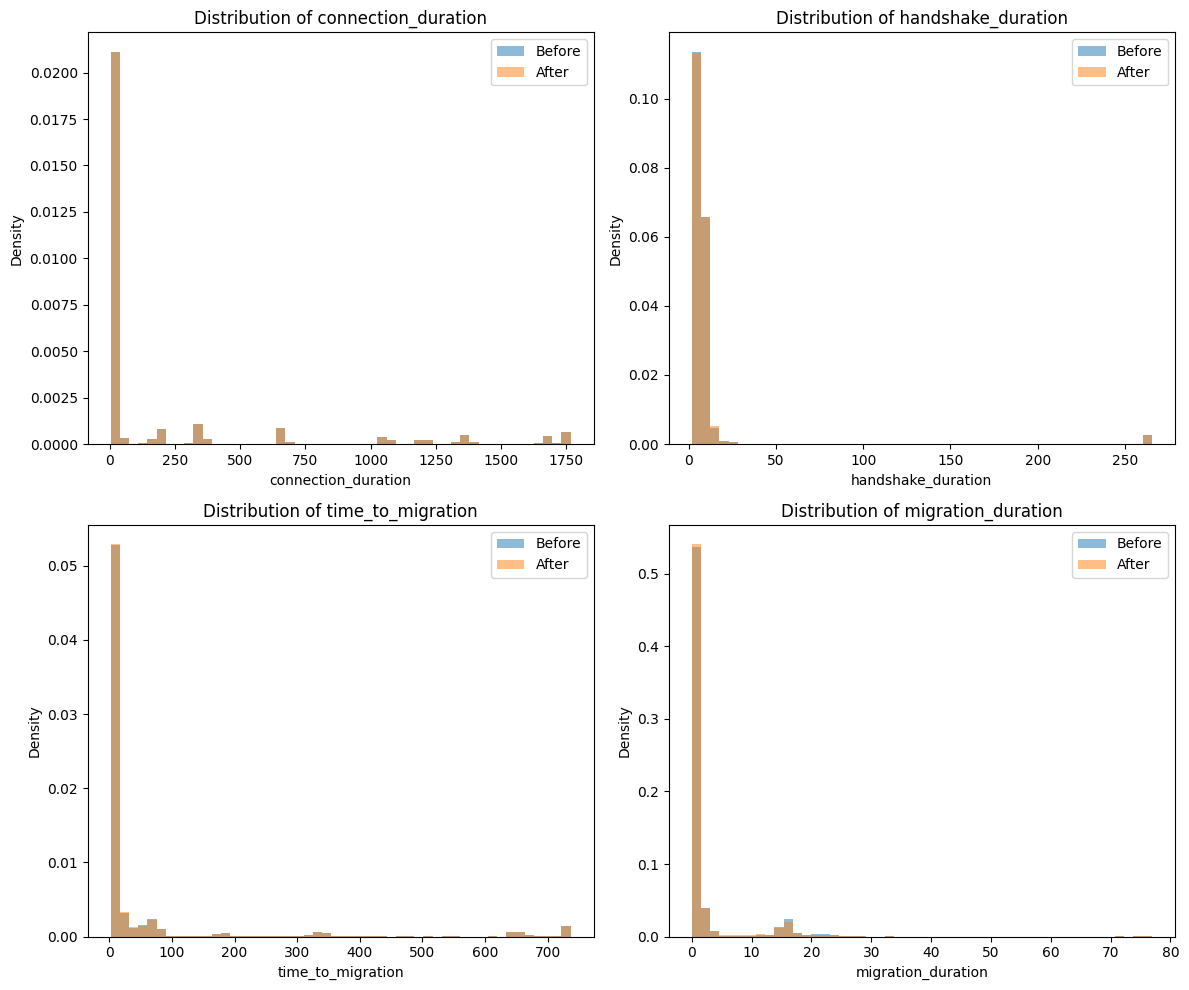

In [15]:
# Visualize the effect of post-processing
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, col in zip(axes.flatten(), existing_cols):
    ax.hist(df[col], bins=50, alpha=0.5, label='Before', density=True)
    ax.hist(df_processed[col], bins=50, alpha=0.5, label='After', density=True)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

## Save Post-Processed Data

In [ ]:
# Rename back to original column name if needed
if CONNECTION_DURATION_COL != "connection_duration":
    df_processed = df_processed.rename(columns={"connection_duration": CONNECTION_DURATION_COL})

# Save the post-processed data
df_processed.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved post-processed data to: {OUTPUT_PATH}")
print(f"Total rows: {len(df_processed)}")

In [ ]:
# Quick sanity check on saved data
df_check = pd.read_csv(OUTPUT_PATH)
print(f"\nVerification - loaded {len(df_check)} rows from saved file")
df_check.head()